# Adversarial Debiasing from Scratch

This notebook implements a fairness-aware machine learning model using the **Predictor-Adversary** architecture (Adversarial Debiasing).

### The Concept
We train two neural networks simultaneously in a min-max game:
1.  **The Predictor:** Tries to predict the target (Income > $50k) accurately.
2.  **The Adversary:** Tries to predict the sensitive attribute (Race) based *only* on the Predictor's output (or hidden state).

**Goal:** The Predictor tries to minimize its own classification error *minus* the Adversary's ability to guess the sensitive attribute. This forces the Predictor to learn a representation that contains information about Income but *hides* information about Race.

### Architecture
$$ \min_{\theta_P} \max_{\theta_A} [ \mathcal{L}_{Predictor} - \lambda \cdot \mathcal{L}_{Adversary} ] $$

Where $\lambda$ controls the trade-off between accuracy and fairness.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
import os

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load Data

In [2]:
DATA_PATH = "../../resources/datasets/acs-income-ca/train.csv"
TEST_PATH = "../../resources/datasets/acs-income-ca/test.csv"

print("Loading data...")
df_train = pd.read_csv(DATA_PATH)
df_test = pd.read_csv(TEST_PATH)

# Combine for consistent preprocessing
df_full = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

# Define Columns
TARGET_COL = "PINCP"
SENSITIVE_COL = "RAC1P"
CATEGORICAL_COLS = ["COW", "MAR", "RELP", "SCHL", "SEX", "OCCP", "POBP"]
NUMERICAL_COLS = ["AGEP", "WKHP"]

Loading data...


## 2. Preprocessing

In [3]:
print("Preprocessing...")

# Encode Target
df_full[TARGET_COL] = df_full[TARGET_COL].astype(int)

# Encode Sensitive Attribute (Race)
# We will focus on White (1) vs Non-White (Others) for binary adversarial training simplicity, 
# or keep it multi-class. Let's keep it multi-class for the adversary.
le_race = LabelEncoder()
df_full[SENSITIVE_COL] = le_race.fit_transform(df_full[SENSITIVE_COL])
n_sensitive_classes = len(le_race.classes_)
print(f"Sensitive Attribute Classes: {n_sensitive_classes}")

# One-Hot Encode Categorical Features
df_encoded = pd.get_dummies(df_full, columns=CATEGORICAL_COLS, drop_first=True)

# Scale Numerical Features
scaler = StandardScaler()
df_encoded[NUMERICAL_COLS] = scaler.fit_transform(df_encoded[NUMERICAL_COLS])

# Split back into Train/Test
train_size = len(df_train)
train_data = df_encoded.iloc[:train_size]
test_data = df_encoded.iloc[train_size:]

# Prepare Tensors
def df_to_tensor(df):
    X = df.drop([TARGET_COL, SENSITIVE_COL], axis=1).values.astype(np.float32)
    y = df[TARGET_COL].values.astype(np.float32).reshape(-1, 1)
    z = df[SENSITIVE_COL].values.astype(np.longlong) # Class indices for CrossEntropy
    return torch.tensor(X), torch.tensor(y), torch.tensor(z)

X_train, y_train, z_train = df_to_tensor(train_data)
X_test, y_test, z_test = df_to_tensor(test_data)

# Create DataLoaders
BATCH_SIZE = 1024
train_dataset = TensorDataset(X_train, y_train, z_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(X_test, y_test, z_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

Preprocessing...
Sensitive Attribute Classes: 9
Train Shape: torch.Size([156532, 800])
Test Shape: torch.Size([39133, 800])


## 3. Define Models

In [4]:
class Predictor(nn.Module):
    def __init__(self, input_dim):
        super(Predictor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Logits for Binary Classification
        )
        
    def forward(self, x):
        return self.net(x)

class Adversary(nn.Module):
    def __init__(self, n_sensitive_classes):
        super(Adversary, self).__init__()
        # Input is the output of the Predictor (1 logit)
        # Or we can take the last hidden layer of predictor. 
        # Taking the output logit is standard for "output-blindness".
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, n_sensitive_classes) # Logits for Multi-class Classification
        )
        
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]

# Initialize Models
predictor = Predictor(input_dim).to(device)
adversary = Adversary(n_sensitive_classes).to(device)

# Optimizers
# We use separate optimizers
opt_predictor = optim.Adam(predictor.parameters(), lr=0.001)
opt_adversary = optim.Adam(adversary.parameters(), lr=0.001)

# Loss Functions
criterion_pred = nn.BCEWithLogitsLoss()
criterion_adv = nn.CrossEntropyLoss()

print(predictor)
print(adversary)

Predictor(
  (net): Sequential(
    (0): Linear(in_features=800, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)
Adversary(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=9, bias=True)
  )
)


## 4. Training Loop

In [5]:
def train_adversarial(predictor, adversary, train_loader, epochs=20, lambda_adv=1.0):
    predictor.train()
    adversary.train()
    
    for epoch in range(epochs):
        total_loss_p = 0
        total_loss_a = 0
        
        for X_batch, y_batch, z_batch in train_loader:
            X_batch, y_batch, z_batch = X_batch.to(device), y_batch.to(device), z_batch.to(device)
            
            # --- 1. Train Adversary ---
            # We want Adversary to minimize CrossEntropy(Adv(Pred(X)), Z)
            # But we don't want to update Predictor here, so we detach Predictor's output
            
            opt_adversary.zero_grad()
            
            with torch.no_grad():
                pred_logits = predictor(X_batch)
            
            adv_logits = adversary(pred_logits)
            loss_a = criterion_adv(adv_logits, z_batch)
            
            loss_a.backward()
            opt_adversary.step()
            
            # --- 2. Train Predictor ---
            # We want Predictor to minimize BCE(Pred(X), Y) - lambda * CrossEntropy(Adv(Pred(X)), Z)
            # Actually, minimizing (Loss_P - lambda * Loss_A) is equivalent to:
            # Minimizing Loss_P AND Maximizing Loss_A (making it hard for adversary)
            
            opt_predictor.zero_grad()
            
            pred_logits = predictor(X_batch)
            
            # Predictor Task Loss
            loss_p_task = criterion_pred(pred_logits, y_batch)
            
            # Adversary Loss (re-calculated with gradients flowing back to Predictor)
            adv_logits_for_p = adversary(pred_logits)
            loss_a_for_p = criterion_adv(adv_logits_for_p, z_batch)
            
            # Total Loss for Predictor
            # We subtract lambda * loss_a because we want to MAXIMIZE the adversary's error
            # (i.e., minimize the negative of the error)
            # However, standard implementation often uses Gradient Reversal Layer.
            # Here, we simply subtract the loss.
            
            loss_p_total = loss_p_task - (lambda_adv * loss_a_for_p)
            
            loss_p_total.backward()
            opt_predictor.step()
            
            total_loss_p += loss_p_task.item()
            total_loss_a += loss_a.item()
            
        avg_p = total_loss_p / len(train_loader)
        avg_a = total_loss_a / len(train_loader)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Pred Loss: {avg_p:.4f} | Adv Loss: {avg_a:.4f}")

# Train
print("Training Adversarial Model...")
train_adversarial(predictor, adversary, train_loader, epochs=50, lambda_adv=5.0) 
# lambda_adv controls the strength of fairness constraint. Higher = More Fair, Less Accurate.

Training Adversarial Model...
Epoch 5/50 | Pred Loss: 0.4240 | Adv Loss: 1.1785
Epoch 10/50 | Pred Loss: 0.4110 | Adv Loss: 1.1790
Epoch 15/50 | Pred Loss: 0.4011 | Adv Loss: 1.1794
Epoch 20/50 | Pred Loss: 0.3904 | Adv Loss: 1.1796
Epoch 25/50 | Pred Loss: 0.3807 | Adv Loss: 1.1796
Epoch 30/50 | Pred Loss: 0.3733 | Adv Loss: 1.1797
Epoch 35/50 | Pred Loss: 0.3667 | Adv Loss: 1.1797
Epoch 40/50 | Pred Loss: 0.3613 | Adv Loss: 1.1797
Epoch 45/50 | Pred Loss: 0.3562 | Adv Loss: 1.1798
Epoch 50/50 | Pred Loss: 0.3539 | Adv Loss: 1.1799


## 5. Evaluation

In [6]:
def evaluate_fairness(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    all_sensitive = []
    
    with torch.no_grad():
        for X_b, y_b, z_b in loader:
            X_b = X_b.to(device)
            logits = model(X_b)
            preds = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(y_b.numpy())
            all_sensitive.extend(z_b.numpy())
            
    return np.array(all_preds).flatten(), np.array(all_targets).flatten(), np.array(all_sensitive).flatten()

y_pred, y_true, z_sensitive = evaluate_fairness(predictor, test_loader)

# Metrics
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# Fairness Metrics (Demographic Parity)
# We need to map back the sensitive attribute indices to original labels if possible, 
# but for now we just use the indices.
# 1 = White (in our encoding logic usually, but let's check), others are others.

from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=z_sensitive)
eo_diff = equalized_odds_difference(y_true, y_pred, sensitive_features=z_sensitive)

print(f"Demographic Parity Difference: {dp_diff:.4f}")
print(f"Equalized Odds Difference: {eo_diff:.4f}")

# Detailed Rates
print("\nSelection Rates by Group:")
unique_groups = np.unique(z_sensitive)
for g in unique_groups:
    mask = z_sensitive == g
    rate = y_pred[mask].mean()
    count = mask.sum()
    # Try to decode if possible, otherwise just print ID
    try:
        label = le_race.inverse_transform([g])[0]
    except:
        label = g
    print(f"  Group {label} (ID {g}): {rate:.4f} ({count} samples)")

Test Accuracy: 0.8049
Demographic Parity Difference: 0.1858
Equalized Odds Difference: 0.2510

Selection Rates by Group:
  Group 1.0 (ID 0): 0.4183 (24193 samples)
  Group 2.0 (ID 1): 0.3389 (1673 samples)
  Group 3.0 (ID 2): 0.2957 (257 samples)
  Group 4.0 (ID 3): 0.3333 (3 samples)
  Group 5.0 (ID 4): 0.2857 (84 samples)
  Group 6.0 (ID 5): 0.4127 (6680 samples)
  Group 7.0 (ID 6): 0.3333 (123 samples)
  Group 8.0 (ID 7): 0.2325 (4498 samples)
  Group 9.0 (ID 8): 0.3551 (1622 samples)


## 6. Visualization

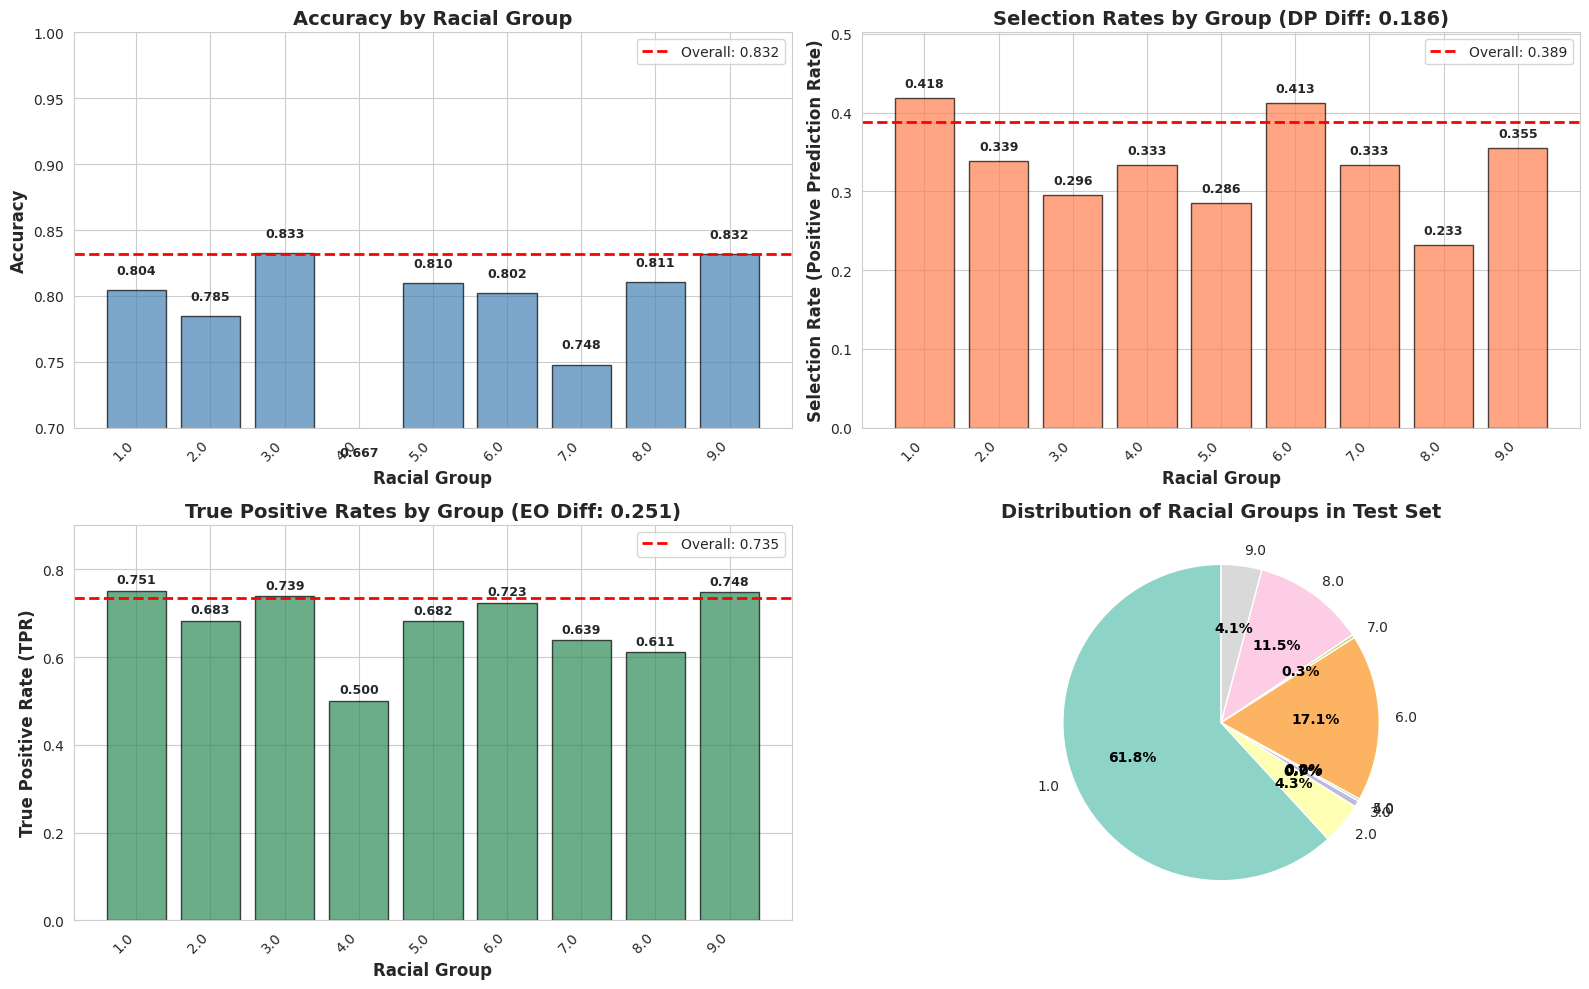


FAIRNESS SUMMARY

Overall Test Accuracy: 0.8317
Demographic Parity Difference: 0.1858
Equalized Odds Difference: 0.2510

Lambda (fairness weight): 5.0
Training epochs: 50

Fairness Target: NOT MET ✗


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)

# Prepare data for visualization
unique_groups = np.unique(z_sensitive)
group_labels = []
selection_rates = []
true_positive_rates = []
group_sizes = []

for g in unique_groups:
    mask = z_sensitive == g
    try:
        label = le_race.inverse_transform([g])[0]
    except:
        label = f"Group {g}"
    
    group_labels.append(label)
    selection_rates.append(y_pred[mask].mean())
    
    # True Positive Rate (TPR) - only for positive class
    true_pos_mask = mask & (y_true == 1)
    if true_pos_mask.sum() > 0:
        tpr = y_pred[true_pos_mask].mean()
    else:
        tpr = 0
    true_positive_rates.append(tpr)
    group_sizes.append(mask.sum())

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Accuracy by Group
accuracies = []
for g in unique_groups:
    mask = z_sensitive == g
    acc = accuracy_score(y_true[mask], y_pred[mask])
    accuracies.append(acc)

ax1 = axes[0, 0]
bars1 = ax1.bar(range(len(group_labels)), accuracies, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axhline(y=acc, color='red', linestyle='--', linewidth=2, label=f'Overall: {acc:.3f}')
ax1.set_xlabel('Racial Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy by Racial Group', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(group_labels)))
ax1.set_xticklabels(group_labels, rotation=45, ha='right')
ax1.legend(fontsize=10)
ax1.set_ylim([0.7, 1.0])
for i, (bar, val) in enumerate(zip(bars1, accuracies)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Selection Rates (Demographic Parity)
ax2 = axes[0, 1]
bars2 = ax2.bar(range(len(group_labels)), selection_rates, color='coral', alpha=0.7, edgecolor='black')
overall_rate = y_pred.mean()
ax2.axhline(y=overall_rate, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall_rate:.3f}')
ax2.set_xlabel('Racial Group', fontsize=12, fontweight='bold')
ax2.set_ylabel('Selection Rate (Positive Prediction Rate)', fontsize=12, fontweight='bold')
ax2.set_title(f'Selection Rates by Group (DP Diff: {dp_diff:.3f})', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(group_labels)))
ax2.set_xticklabels(group_labels, rotation=45, ha='right')
ax2.legend(fontsize=10)
ax2.set_ylim([0, max(selection_rates) * 1.2])
for i, (bar, val) in enumerate(zip(bars2, selection_rates)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. True Positive Rates (Equal Opportunity)
ax3 = axes[1, 0]
bars3 = ax3.bar(range(len(group_labels)), true_positive_rates, color='seagreen', alpha=0.7, edgecolor='black')
# Calculate overall TPR
overall_tpr = y_pred[y_true == 1].mean() if (y_true == 1).sum() > 0 else 0
ax3.axhline(y=overall_tpr, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall_tpr:.3f}')
ax3.set_xlabel('Racial Group', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
ax3.set_title(f'True Positive Rates by Group (EO Diff: {eo_diff:.3f})', fontsize=14, fontweight='bold')
ax3.set_xticks(range(len(group_labels)))
ax3.set_xticklabels(group_labels, rotation=45, ha='right')
ax3.legend(fontsize=10)
ax3.set_ylim([0, max(true_positive_rates) * 1.2])
for i, (bar, val) in enumerate(zip(bars3, true_positive_rates)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Group Distribution
ax4 = axes[1, 1]
colors = plt.cm.Set3(range(len(group_labels)))
wedges, texts, autotexts = ax4.pie(group_sizes, labels=group_labels, autopct='%1.1f%%', 
                                     colors=colors, startangle=90, textprops={'fontsize': 10})
ax4.set_title('Distribution of Racial Groups in Test Set', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('adversarial_debiasing_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("FAIRNESS SUMMARY")
print("="*80)
print(f"\nOverall Test Accuracy: {acc:.4f}")
print(f"Demographic Parity Difference: {dp_diff:.4f}")
print(f"Equalized Odds Difference: {eo_diff:.4f}")
print(f"\nLambda (fairness weight): 5.0")
print(f"Training epochs: 50")
print(f"\nFairness Target: {'ACHIEVED' if dp_diff < 0.10 and eo_diff < 0.10 else 'NOT MET ✗'}")